# Relação das colunas com o resultado (`type`)

1. Distribuição de cada coluna por tipo (boxplots) e proporção de `sex` em cada tipo
2. Médias de cada coluna por tipo
3. Ranking de relação com `type`: correlação de Spearman, ANOVA (F) e informação mútua
4. Importância por permutação (Random Forest)

In [1]:
# Instale uma vez, se precisar: !pip install pandas matplotlib seaborn scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

%matplotlib inline

In [2]:
CAMINHO = "abalone_dataset.csv"  # troque pelo caminho do seu arquivo
ALVO = "type"

df = pd.read_csv(CAMINHO)
colunas_numericas = [c for c in df.columns if c not in ["sex", ALVO]]
df.head()

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,type
0,M,0.535,0.420,0.150,0.6995,0.2575,0.1530,0.2400,3
1,I,0.510,0.380,0.115,0.5155,0.2150,0.1135,0.1660,1
2,I,0.185,0.130,0.045,0.0290,0.0120,0.0075,0.0095,1
3,M,0.550,0.450,0.170,0.8100,0.3170,0.1570,0.2200,3
4,I,0.535,0.415,0.150,0.5765,0.3595,0.1350,0.2250,1


## 1. Cada coluna por tipo

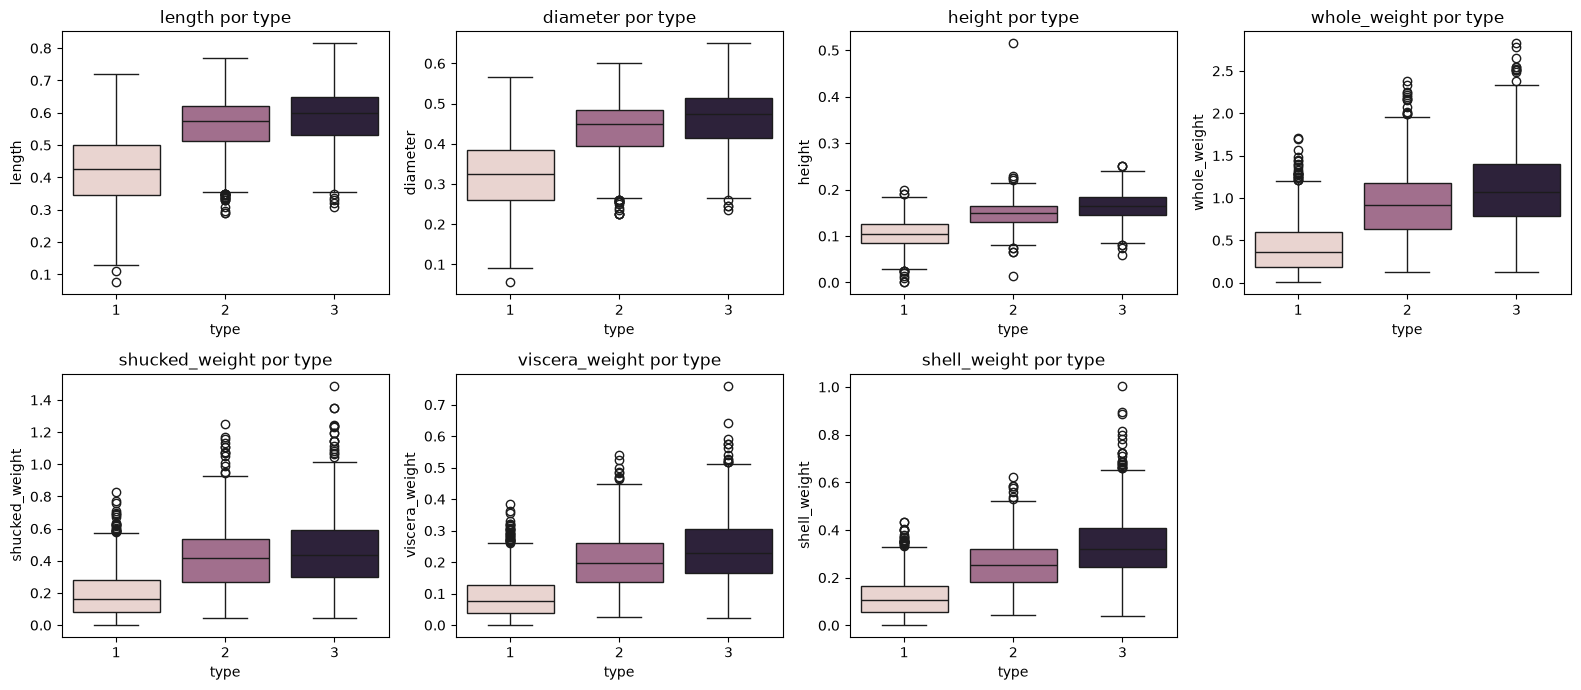

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), colunas_numericas):
    sns.boxplot(data=df, x=ALVO, y=col, hue=ALVO, legend=False, ax=ax)
    ax.set_title(f"{col} por {ALVO}")
for ax in axes.ravel()[len(colunas_numericas):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

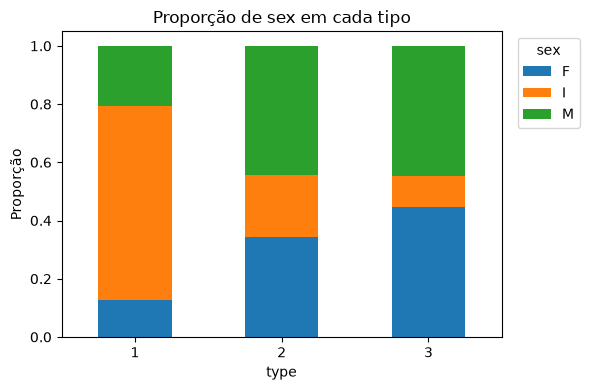

In [4]:
# Proporção de cada sexo dentro de cada tipo
prop = pd.crosstab(df[ALVO], df["sex"], normalize="index")
prop.plot(kind="bar", stacked=True, figsize=(6, 4), rot=0)
plt.title("Proporção de sex em cada tipo")
plt.ylabel("Proporção")
plt.legend(title="sex", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 2. Média de cada coluna por tipo

In [5]:
df.groupby(ALVO)[colunas_numericas].mean().round(3).T

type,1,2,3
length,0.419,0.560,0.590
diameter,0.320,0.437,0.464
height,0.105,0.148,0.163
whole_weight,0.430,0.923,1.118
shucked_weight,0.197,0.416,0.460
viscera_weight,0.093,0.203,0.242
shell_weight,0.121,0.257,0.333


## 3. Ranking: quanto cada coluna se relaciona com o tipo

- **Spearman**: correlação de posição entre a coluna e o tipo (de -1 a 1). Boa quando o tipo tem ordem (1 < 2 < 3).
- **F (ANOVA)**: quanto as médias dos tipos diferem em relação à variação dentro de cada tipo. Maior = mais separação.
- **Informação mútua**: captura qualquer tipo de relação, inclusive não linear. Maior = mais informação sobre o tipo.

In [6]:
X = df[colunas_numericas]
y = df[ALVO]

ranking = pd.DataFrame({
    "spearman": [df[col].corr(y, method="spearman") for col in colunas_numericas],
    "F_anova": f_classif(X, y)[0],
    "info_mutua": mutual_info_classif(X, y, random_state=0),
}, index=colunas_numericas)

ranking = ranking.sort_values("info_mutua", ascending=False)
ranking.round(3)

,spearman,F_anova,info_mutua
shell_weight,0.652,1076.259,0.329
height,0.621,1023.167,0.262
whole_weight,0.599,870.168,0.249
diameter,0.594,1046.287,0.248
viscera_weight,0.588,812.642,0.239
length,0.578,978.995,0.229
shucked_weight,0.517,595.606,0.206


Por sexo

In [7]:
import pandas as pd
from IPython.display import display
from sklearn.feature_selection import f_classif, mutual_info_classif

colunas_numericas = [c for c in df.columns if c not in ["sex", "type"]]

resultados = {}
for sexo, d in df.groupby("sex"):
    X, y = d[colunas_numericas], d["type"]
    resultados[sexo] = pd.DataFrame({
        "spearman": [d[c].corr(y, method="spearman") for c in colunas_numericas],
        "F_anova": f_classif(X, y)[0],
        "info_mutua": mutual_info_classif(X, y, random_state=0),
    }, index=colunas_numericas).sort_values("info_mutua", ascending=False)

    print(f"=== sex = {sexo} (n = {len(d)}) ===")
    display(resultados[sexo].round(3))

# Comparação lado a lado, uma tabela por medida
for metrica in ["spearman", "F_anova", "info_mutua"]:
    print(f"\n{metrica}")
    display(pd.DataFrame({s: r[metrica] for s, r in resultados.items()}).round(3))

=== sex = F (n = 953) ===


,spearman,F_anova,info_mutua
shell_weight,0.374,87.599,0.139
height,0.347,74.904,0.116
whole_weight,0.287,55.658,0.092
viscera_weight,0.271,51.658,0.077
length,0.263,57.181,0.053
shucked_weight,0.155,25.483,0.053
diameter,0.291,66.232,0.050


=== sex = I (n = 1042) ===


,spearman,F_anova,info_mutua
shell_weight,0.629,394.510,0.248
height,0.617,292.837,0.241
viscera_weight,0.590,310.984,0.233
length,0.595,256.054,0.231
whole_weight,0.602,337.469,0.231
diameter,0.601,268.979,0.225
shucked_weight,0.544,240.637,0.178


=== sex = M (n = 1137) ===


...

,F,I,M
diameter,0.291,0.601,0.388
height,0.347,0.617,0.431
length,0.263,0.595,0.367
shell_weight,0.374,0.629,0.499
shucked_weight,0.155,0.544,0.279
viscera_weight,0.271,0.590,0.366
whole_weight,0.287,0.602,0.396



F_anova


,F,I,M
diameter,66.232,268.979,142.606
height,74.904,292.837,139.872
length,57.181,256.054,131.306
shell_weight,87.599,394.510,192.309
shucked_weight,25.483,240.637,71.363
viscera_weight,51.658,310.984,109.029
whole_weight,55.658,337.469,124.610



info_mutua


,F,I,M
diameter,0.050,0.225,0.115
height,0.116,0.241,0.109
length,0.053,0.231,0.120
shell_weight,0.139,0.248,0.190
shucked_weight,0.053,0.178,0.063
viscera_weight,0.077,0.233,0.105
whole_weight,0.092,0.231,0.092


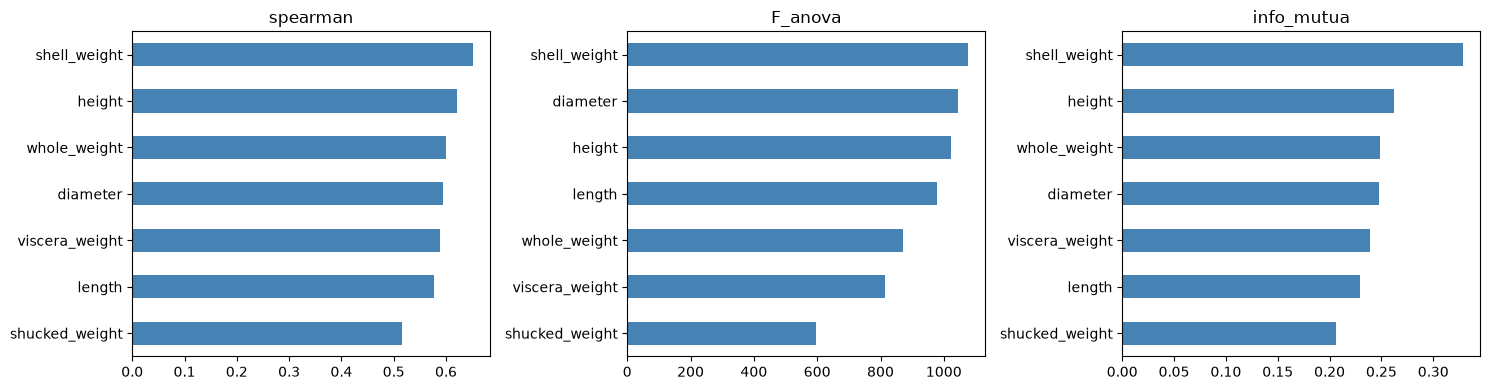

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["spearman", "F_anova", "info_mutua"]):
    ranking[col].sort_values().plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Importância por permutação (Random Forest)

Mede quanto a acurácia cai, num conjunto de teste, quando os valores de uma coluna são embaralhados. Quanto maior a queda, mais o modelo depende da coluna.